# 4.5d — Détection SOTA : un second wrapper, LibreYOLO, et la leçon comparative

[← Série 04-Vision](README.md) | [4.5b — YOLO sous ultralytics](4.5b-Detection-SOTA-Ultralytics.ipynb) | [4.6 — scènes difficiles →](4.6-Detection-Ultralytics-Difficult-Scenes.ipynb) | [4.6b — le renversement : camouflage adversarial →](4.6b-Detection-Adversarial-Camouflage.ipynb)

Le [4.5b](4.5b-Detection-SOTA-Ultralytics.ipynb) a mesuré ce qu'achète et ce que masque **un** wrapper (`ultralytics`). Une seule enseigne, c'est une opinion ; deux, c'est une mesure. Ce notebook ajoute le wrapper concurrent **`libreyolo`** — même API à trois lignes, même format de données YOLO, catalogue plus large — et transforme l'assertion « le wrapper est un choix d'ingénieur » en comparatif chiffré :

- **YOLOv9-tiny** fine-tuné sur **le terrain exact du 4.4** au budget canonique (mille images × six époques, `imgsz=96`) — la parité directe avec les lignes YOLO du 4.5b ;
- **YOLOv9-tiny End-to-End**, la variante **sans NMS** de la même génération et du même gabarit — la prédiction d'ensemble un-pour-un, idée centrale de DETR revenue dans la famille YOLO : la fenêtre architecturale du comparatif, **à variables égales par ailleurs** ;
- l'évaluation **à notre protocole maison** (`ap_voc` du 4.4 repris verbatim) — jamais le mAP auto-rapporté comme seule mesure ;
- le **tableau final étendu** : les lignes des carnets précédents plus les deux nouvelles, avec une colonne inédite — **la licence du code et celle des checkpoints**. Le choix d'un modèle est aussi un choix juridique, et il se lit à la source avant usage ;
- trois exercices qui percent le wrapper : seuil de confiance, carré de l'`imgsz`, et le confronter à notre propre bâton de mesure.


## 1. Position : un modèle, mais surtout une seconde enseigne

Un wrapper de vision embarque un modèle, un format de données, une boucle d'entraînement et des mesures auto-rapportées. Le 4.5b en a disséqué un ; la question de ce carnet est ce qui **change** et ce qui **ne change pas** quand on en prend un deuxième :

- le **format YOLO** (images + labels normalisés + `data.yaml`) est un standard de fait : le convertisseur du 4.5b se réutilise quasi tel quel — c'est le premier argument mesurable pour un second wrapper, le coût de portage est proche de zéro ;
- les **hyperparamètres enfuis** diffèrent : chaque wrapper apporte ses recettes d'augmentation, ses planchers d'apprentissage — sur notre terrain minuscule, ce sont eux qui dominent, pas la profondeur des modèles ;
- la **licence** n'est pas la même : ultralytics distribue code et poids en AGPL-3.0 ; le paquet `libreyolo` est MIT et ses checkpoints sont vérifiés **un par un** au §4 — deux niveaux de lecture que la colonne finale rend explicites.

C'est le dernier étage de la pile : le même problème de détection, mesuré from scratch (4.4), lib bas niveau (4.5), framework intégré (4.5b), **et maintenant deux frameworks intégrés face à face**.


In [1]:
import time
from importlib.metadata import version as _pkg_version

import cv2
import matplotlib.pyplot as plt
import numpy as np
import requests
import torch
from libreyolo import LibreYOLO

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = 0 if torch.cuda.is_available() else "cpu"
print("device:", "cuda" if DEVICE == 0 else "cpu",
      "| torch", torch.__version__, "| libreyolo", _pkg_version("libreyolo"))

IMG = 96          # cote de l'image : identique au 4.4 (multiple de 32, impose par imgsz)

device: cuda | torch 2.14.0+cu126 | libreyolo 1.6.0


## 2. Le terrain : toujours celui du 4.4

Générateur **verbatim**, mêmes graines — mêmes deux mille images de train, mêmes quatre cents images et huit cent dix-sept objets de validation que les carnets 4.4 à 4.6. La comparaison finale de ce carnet s'ajoute à un tableau mesuré sur les mêmes images depuis le début de l'epic.


In [2]:
def iou_np(a, b):
    """IoU de deux boites (x0, y0, w, h) en NumPy pur (scalaire)."""
    ix = max(0.0, min(a[0] + a[2], b[0] + b[2]) - max(a[0], b[0]))
    iy = max(0.0, min(a[1] + a[3], b[1] + b[3]) - max(a[1], b[1]))
    inter = ix * iy
    union = a[2] * a[3] + b[2] * b[3] - inter
    return inter / union if union > 0 else 0.0


def make_image(rng):
    img = rng.normal(0, 0.08, (IMG, IMG)).astype(np.float32)
    yy, xx = np.mgrid[0:IMG, 0:IMG]
    for _ in range(rng.integers(2, 5)):          # fond : blobs lents
        cy, cx = rng.integers(0, IMG, 2)
        s = rng.uniform(18, 50)
        img += 0.10 * rng.uniform(0.6, 1.3) * np.exp(-(((yy - cy) ** 2 + (xx - cx) ** 2) / (2 * s * s)))
    boxes = []
    for _ in range(rng.integers(1, 4)):          # 1 a 3 objets
        kind = rng.choice(["rect", "ellipse"])
        for _try in range(30):                   # placement sans recouvrement fort
            w = int(rng.uniform(14, 44))
            h = int(max(10, min(48, w * rng.uniform(0.35, 2.9))))
            x0 = int(rng.integers(2, IMG - w - 2))
            y0 = int(rng.integers(2, IMG - h - 2))
            cand = (x0, y0, w, h)
            if all(iou_np(cand, b) < 0.25 for b in boxes):
                boxes.append(cand)
                break
    for (x0, y0, w, h) in boxes:
        amp = rng.uniform(0.7, 1.2)
        if kind == "rect":
            img[y0:y0 + h, x0:x0 + w] += amp
        else:
            sub = img[y0:y0 + h, x0:x0 + w]
            ey, ex = np.mgrid[0:h, 0:w]
            mask = (((ex - w / 2) / (w / 2)) ** 2 + ((ey - h / 2) / (h / 2)) ** 2) <= 1.0
            img[y0:y0 + h, x0:x0 + w] = np.where(mask, sub + amp, sub)
    return np.clip(img, -1.5, 2.5), boxes


def make_split(n, seed):
    rng = np.random.default_rng(seed)
    xs, bs = [], []
    for _ in range(n):
        img, boxes = make_image(rng)
        xs.append(img)
        bs.append(torch.tensor(boxes, dtype=torch.float32))
    return torch.tensor(np.stack(xs)).unsqueeze(1), bs


Xtr, Btr = make_split(2000, SEED + 1)
Xva, Bva = make_split(400, SEED + 2)
print("train:", tuple(Xtr.shape), "| val:", tuple(Xva.shape),
      "| objets GT val:", sum(len(b) for b in Bva))

train: (2000, 1, 96, 96) | val: (400, 1, 96, 96) | objets GT val: 817


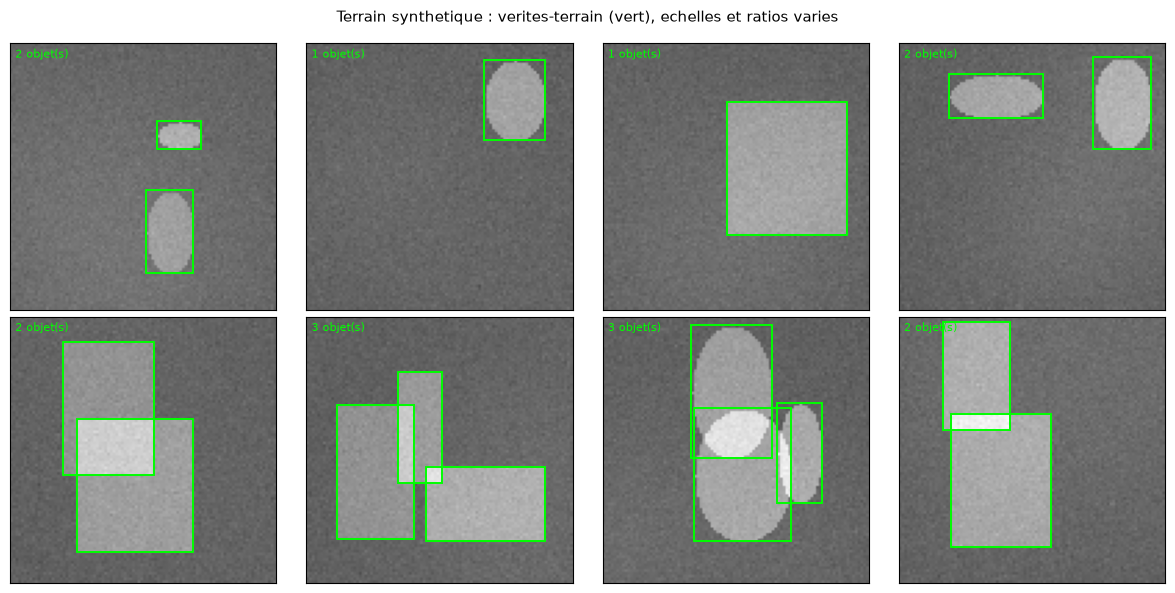

In [3]:
def draw_boxes(ax, boxes, color, label):
    for (x0, y0, w, h) in boxes:
        ax.add_patch(plt.Rectangle((x0 - 0.5, y0 - 0.5), w, h, fill=False,
                                   edgecolor=color, linewidth=1.4))
    ax.text(0.02, 0.98, label, transform=ax.transAxes, va="top",
            fontsize=8, color=color)


fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])
for i, ax in enumerate(axes.flat):
    img, boxes = Xva[i + 40][0].numpy(), [tuple(b) for b in Bva[i + 40].tolist()]
    ax.imshow(img, cmap="gray", vmin=-1.5, vmax=2.5)
    draw_boxes(ax, boxes, "lime", f"{len(boxes)} objet(s)")
fig.suptitle("Terrain synthetique : verites-terrain (vert), echelles et ratios varies", fontsize=11)
plt.tight_layout()
plt.show()

## 3. Le format YOLO : le convertisseur du 4.5b se réutilise

Premier résultat du comparatif, avant tout entraînement : **le coût de portage d'un wrapper à l'autre est la conversion de données — et elle est déjà payée**. Le format imposé par `ultralytics` (images uint8, labels normalisés, `data.yaml`) est celui que `libreyolo` consomme aussi. La cellule ci-dessous est celle du 4.5b à une différence près : le split d'entraînement est **matérialisé en mille images** (le budget canonique), là où le 4.5b utilisait l'option `fraction` d'ultralytics — `libreyolo` ne la propose pas, et un sous-ensemble explicite vaut mieux qu'un paramètre enfui.


In [4]:
import tempfile
from pathlib import Path

DS = Path(tempfile.mkdtemp(prefix="terrain_ly_"))


def write_yolo_split(X, B, split):
    (DS / "images" / split).mkdir(parents=True, exist_ok=True)
    (DS / "labels" / split).mkdir(parents=True, exist_ok=True)
    for i, (img, boxes) in enumerate(zip(X, B)):
        u8 = (((img - img.min()) / (img.max() - img.min() + 1e-6)) * 255).astype(np.uint8)
        cv2.imwrite(str(DS / "images" / split / f"{i:05d}.png"), u8)
        lines = [f"0 {(x0 + w / 2) / IMG} {(y0 + h / 2) / IMG} {w / IMG} {h / IMG}"
                 for (x0, y0, w, h) in boxes]
        (DS / "labels" / split / f"{i:05d}.txt").write_text(
            "\n".join(lines), encoding="utf-8")


write_yolo_split([x[0].numpy() for x in Xtr[:1000]], [b.tolist() for b in Btr[:1000]], "train")
write_yolo_split([x[0].numpy() for x in Xva], [b.tolist() for b in Bva], "val")
(DS / "data.yaml").write_text(
    f"path: {DS.as_posix()}\ntrain: images/train\nval: images/val\nnc: 1\nnames: ['objet']\n",
    encoding="utf-8")
n_tr = len(list((DS / "images" / "train").glob("*.png")))
n_va = len(list((DS / "images" / "val").glob("*.png")))
print(f"dataset YOLO pret : {n_tr} train / {n_va} val, "
      f"{sum(len(b) for b in Bva)} GT val, 1 classe")

dataset YOLO pret : 1000 train / 400 val, 817 GT val, 1 classe


## 4. Licence des checkpoints : vérifiée à la source, avant usage

Le dépôt `LibreYOLO/libreyolo` est **MIT pour le code**, mais ses poids pré-entraînés vivent sur Hugging Face avec des **licences par checkpoint** — dont certaines sont non permissives (le carve-out est explicite dans leur LICENSE). La règle de ce carnet, héritée du 4.5/4.5b : le choix d'un checkpoint inclut sa licence, au même titre que son SHA. La cellule ci-dessous lit la carte du modèle à la source (API Hugging Face), affiche licence et empreinte, et **refuse** (échec d'assertion) tout checkpoint non permissif — on n'utilise que ce qui est proprement réutilisable dans un cadre d'enseignement.


In [5]:
CHECKPOINTS = {"LibreYOLO9t": "LibreYOLO/LibreYOLO9t",
               "LibreYOLO9E2ET": "LibreYOLO/LibreYOLO9E2ET"}
LICENCES = {}
for ckpt, repo in CHECKPOINTS.items():
    card = requests.get(f"https://huggingface.co/api/models/{repo}", timeout=20).json()
    lic = (card.get("cardData") or {}).get("license", "inconnue")
    LICENCES[ckpt] = {"licence": lic, "sha": (card.get("sha") or "?")[:12]}
    print(f"{ckpt:14s} licence {lic:12s} sha {LICENCES[ckpt]['sha']}  ({repo})")

PERMISSIVES = {"mit", "apache-2.0", "bsd-3-clause", "bsd-2-clause"}
assert set(v["licence"] for v in LICENCES.values()) <= PERMISSIVES, \
    "checkpoint non permissif : refuse (issue #18403)"
print("code du paquet : MIT | checkpoints : tous permissifs -> utilisables en cours")

LibreYOLO9t    licence mit          sha 66ac39d1ac9b  (LibreYOLO/LibreYOLO9t)


LibreYOLO9E2ET licence mit          sha 113f33368d72  (LibreYOLO/LibreYOLO9E2ET)
code du paquet : MIT | checkpoints : tous permissifs -> utilisables en cours


## 5. Fine-tuning au budget canonique : la parité et la fenêtre

Deux modèles, pas plus — et un choix d'expérience contrôlée :

- **YOLOv9-tiny** (`LibreYOLO9t`) — la *parité directe* : même famille que les lignes YOLO du 4.5b, génération différente, wrapper différent ;
- **YOLOv9-tiny End-to-End** (`LibreYOLO9E2ET`) — même génération, même gabarit, mais **sans NMS** : chaque vérité-terrain est appariée un-pour-un à une prédiction unique, l'idée centrale que DETR a apportée à la détection, revenue dans la famille YOLO. Un seul facteur varie entre les deux lignes du tableau : le régime d'appariement.

Pourquoi pas un DETR-family nano (D-FINE, RT-DETR, GTR), comme l'étude initiale le suggérait ? Mesuré au banc, pas préféré : ces variantes **sélectionnent leurs requêtes par `topk` sur la carte de l'encodeur**. À `imgsz=96` la carte porte trois fois trois positions — moins que les requêtes à sélectionner — et le premier pas d'entraînement échoue (`selected index k out of range` ; reproduit aussi à `imgsz=128`, le plancher réel avoisine les 554 pixels, hors budget canonique). Le DETR classique, lui, est livré **inférence-seule** dans ce paquet (sa recette d'entraînement n'y est pas implémentée). La porte « détection sans NMS » reste ouverte par la travée d'à côté — et le comparatif y gagne : même famille, même taille, un seul facteur qui diffère.


In [6]:
N_TRAIN, EPOCHS = 1000, 6
print("budget commun aux carnets 4.2f/4.2g/4.2j :",
      N_TRAIN, "images x", EPOCHS, "epoques (le 4.2c : 2000 x 12)")


def train_ly(weights, run, nb_classes=1):
    m = LibreYOLO(weights, nb_classes=nb_classes, device=DEVICE)
    torch.manual_seed(SEED)
    t0 = time.time()
    m.train(data=str(DS / "data.yaml"), epochs=EPOCHS, imgsz=IMG, batch=16,
            device=DEVICE, workers=0, seed=SEED, project=str(DS / "runs"),
            name=run, exist_ok=True, patience=EPOCHS + 5)
    return m, time.time() - t0


MODEL_Y9T, T_Y9T = train_ly("LibreYOLO9t.pt", "yolov9t")
info_y9t = MODEL_Y9T.info(verbose=False)
print(f"yolov9t    : {info_y9t['parameters'] / 1e6:.2f} M params, fine-tune {T_Y9T:.0f} s")

budget commun aux carnets 4.2f/4.2g/4.2j : 1000 images x 6 epoques (le 4.2c : 2000 x 12)


2026-10-01 10:48:15 | INFO     | Using device: cuda


2026-10-01 10:48:15 | INFO     | Setting up training...


2026-10-01 10:48:15 | INFO     | Loading 1000 YOLO annotations from labels/train...


2026-10-01 10:48:17 | INFO     | Loaded 1000 YOLO annotations from labels/train in 1.69s


...

DONE (t=0.27s).
Accumulating evaluation results...
DONE (t=0.04s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.916
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.989
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.977
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.858
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.973
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = -1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.475
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.937
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.937
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.893
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.984
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= la

2026-10-01 10:50:48 | INFO     | New best model saved - Epoch 6: metrics/mAP50-95=0.9157


2026-10-01 10:50:48 | INFO     | Checkpoint saved: <USER_PATH>\AppData\Local\Temp\terrain_ly_dkaktjlg\runs\yolov9t\weights\last.pt


2026-10-01 10:50:48 | INFO     | Training complete in 0.04 hours


yolov9t    : 2.76 M params, fine-tune 156 s


In [7]:
MODEL_E2E, T_E2E = train_ly("LibreYOLO9E2ET.pt", "yolov9t-e2e")
info_e2e = MODEL_E2E.info(verbose=False)
print(f"yolov9t-e2e: {info_e2e['parameters'] / 1e6:.2f} M params, fine-tune {T_E2E:.0f} s")

# GFLOPs a imgsz=96 : le paquet n'expose pas de compteur, PyTorch en embarque un
from torch.utils.flop_counter import FlopCounterMode

def gflops_at_96(model):
    model.model.eval()
    probe = torch.randn(1, 3, IMG, IMG, device=DEVICE)
    fc = FlopCounterMode(display=False)
    with torch.no_grad(), fc:
        model.model(probe)
    return fc.get_total_flops() / 1e9

GFLOPS = {"yolov9t": gflops_at_96(MODEL_Y9T), "yolov9t-e2e": gflops_at_96(MODEL_E2E)}
print("GFLOPs @96 :", {k: round(v, 2) for k, v in GFLOPS.items()})

2026-10-01 10:50:51 | INFO     | Using device: cuda


2026-10-01 10:50:51 | INFO     | Setting up training...


2026-10-01 10:50:51 | INFO     | Loading 1000 YOLO annotations from labels/train...


2026-10-01 10:50:52 | INFO     | Loaded 1000 YOLO annotations from labels/train in 0.56s


2026-10-01 10:50:52 | INFO     | Training dataset: 1000 images


...

2026-10-01 10:52:49 | INFO     | Checkpoint saved: <USER_PATH>\AppData\Local\Temp\terrain_ly_dkaktjlg\runs\yolov9t-e2e\weights\last.pt


2026-10-01 10:52:49 | INFO     | Training complete in 0.03 hours


W1001 10:52:50.471000 33432 Lib\site-packages\torch\utils\flop_counter.py:113] triton not found; flop counting will not work for triton kernels


yolov9t-e2e: 2.60 M params, fine-tune 119 s


GFLOPs @96 : {'yolov9t': 0.17, 'yolov9t-e2e': 0.17}


## 6. Évaluation : notre protocole, pas celui du wrapper

Même discipline que le 4.5b : matching glouton à IoU égale ou supérieure à un demi, précision/rappel courbes au protocole VOC (onze points et tous points), calculés **sur nos prédictions**, pas sur le résumé du wrapper. L'exercice trois confronte justement les deux bâtons.


In [8]:
def iou_t(boxes1, boxes2):
    """IoU vectorisee : (N,4) x (M,4) en (x0,y0,w,h) -> (N,M)."""
    b1, b2 = boxes1.to(DEVICE), boxes2.to(DEVICE)
    ix0 = torch.maximum(b1[:, None, 0], b2[None, :, 0])
    iy0 = torch.maximum(b1[:, None, 1], b2[None, :, 1])
    ix1 = torch.minimum(b1[:, None, 0] + b1[:, None, 2], b2[None, :, 0] + b2[None, :, 2])
    iy1 = torch.minimum(b1[:, None, 1] + b1[:, None, 3], b2[None, :, 1] + b2[None, :, 3])
    iw = (ix1 - ix0).clamp(min=0)
    ih = (iy1 - iy0).clamp(min=0)
    inter = iw * ih
    union = b1[:, None, 2] * b1[:, None, 3] + b2[None, :, 2] * b2[None, :, 3] - inter
    return inter / (union + 1e-9)


# garde-fous : cas ou la reponse est connue
a = torch.tensor([[10.0, 10.0, 20.0, 20.0]])
assert abs(iou_t(a, a).item() - 1.0) < 1e-6                      # identiques -> 1
assert iou_t(a, torch.tensor([[50.0, 50.0, 20.0, 20.0]])).item() < 1e-6   # disjoints -> 0
b = torch.tensor([[20.0, 10.0, 20.0, 20.0]])                     # recouvrement horizontal 50 %
expected = 10.0 * 20.0 / (2 * 400.0 - 200.0)
assert abs(iou_t(a, b).item() - expected) < 1e-6
assert abs(iou_np((10, 10, 20, 20), (20, 10, 20, 20)) - expected) < 1e-9  # parite NumPy
print("IoU : garde-fous OK (identique=1, disjoint=0, moitie=%.4f)" % expected)


def xyxy_yolo(b_xywh):
    """(x0, y0, w, h) numpy -> (x1, y1, x2, y2) torch : corners."""
    t = torch.tensor(b_xywh, dtype=torch.float32)
    return torch.stack([t[:, 0], t[:, 1], t[:, 0] + t[:, 2], t[:, 1] + t[:, 3]], dim=1)


def predict_boxes_ly(model, idx):
    """Boites (N,4) xyxy + scores d'une image de validation, seuils du 4.4."""
    r = model.predict(str(DS / "images" / "val" / f"{idx:05d}.png"),
                      conf=0.5, iou=0.45, imgsz=IMG, device=DEVICE)
    res = r[0] if isinstance(r, list) else r
    return (torch.tensor(res.boxes.xyxy.tolist(), dtype=torch.float32),
            torch.tensor(res.boxes.conf.tolist(), dtype=torch.float32))


def collect_pr_ly(model, B, iou_thr=0.5):
    """Flags TP/FP des detections, meme matching glouton que 4.4/4.5b."""
    tp_s, fp_s, ngt = [], [], 0
    for i in range(len(B)):
        dets, dscores = predict_boxes_ly(model, i)
        gts = xyxy_yolo(B[i])
        matched = torch.zeros(len(gts), dtype=torch.bool)
        for d in dscores.argsort(descending=True).tolist():
            if len(gts):
                ious = iou_t(dets[d:d + 1], gts)[0]
                ious[matched] = -1
                g = int(ious.argmax())
                if ious[g] >= iou_thr:
                    matched[g] = True
                    tp_s.append(float(dscores[d]))
                    continue
            fp_s.append(float(dscores[d]))
        ngt += len(B[i])
    return tp_s, fp_s, ngt


def ap_voc(tp_s, fp_s, ngt):
    flags = np.array([1] * len(tp_s) + [0] * len(fp_s), dtype=np.float64)
    scores = np.array(tp_s + fp_s, dtype=np.float64)
    order = np.argsort(-scores)
    flags, scores = flags[order], scores[order]
    ctp, cfp = np.cumsum(flags), np.cumsum(1 - flags)
    rec = ctp / max(ngt, 1)
    prec = ctp / np.maximum(ctp + cfp, 1e-9)
    mrec = np.concatenate([[0], rec, [1]])
    mpre = np.concatenate([[0], prec, [0]])
    for i in range(len(mpre) - 2, -1, -1):          # monotonie descendante (VOC10)
        mpre[i] = max(mpre[i], mpre[i + 1])
    ap10 = float(np.sum((mrec[1:] - mrec[:-1]) * mpre[1:]))
    ap07 = 0.0
    for t in np.linspace(0, 1, 11):                  # 11-point interpole (VOC07)
        sel = rec >= t
        ap07 += (prec[sel].max() if sel.any() else 0.0) / 11
    return ap07, ap10, rec, prec

IoU : garde-fous OK (identique=1, disjoint=0, moitie=0.3333)


yolov9t     mAP@0.5 sur 400 images / 817 objets GT : VOC07 11-point 0.909 | VOC10 all-point 0.986


yolov9t-e2e mAP@0.5 sur 400 images / 817 objets GT : VOC07 11-point 0.817 | VOC10 all-point 0.897


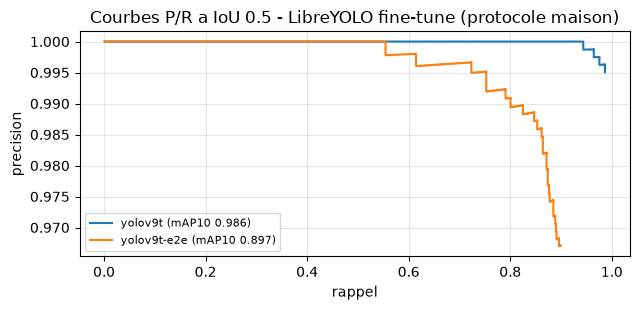

In [9]:
RESULTS = {}
for name, model in (("yolov9t", MODEL_Y9T), ("yolov9t-e2e", MODEL_E2E)):
    tp_s, fp_s, ngt = collect_pr_ly(model, [b.tolist() for b in Bva])
    ap07, ap10, rec, prec = ap_voc(tp_s, fp_s, ngt)
    RESULTS[name] = {"ap07": ap07, "ap10": ap10, "rec": rec, "prec": prec}
    print(f"{name:11s} mAP@0.5 sur {len(Xva)} images / {ngt} objets GT : "
          f"VOC07 11-point {ap07:.3f} | VOC10 all-point {ap10:.3f}")

plt.figure(figsize=(6.5, 3.2))
for name, r in RESULTS.items():
    plt.step(r["rec"], r["prec"], where="post", label=f"{name} (mAP10 {r['ap10']:.3f})")
plt.xlabel("rappel"); plt.ylabel("precision")
plt.title("Courbes P/R a IoU 0.5 - LibreYOLO fine-tune (protocole maison)")
plt.grid(alpha=0.3); plt.legend(fontsize=8); plt.tight_layout(); plt.show()

### Lecture du resultat

**Le plafond du terrain se confirme, enseigne apres enseigne.** `yolov9t` atteint VOC07 0.909 / VOC10 0.986 — exactement les valeurs des modeles NMS du 4.5b (`yolo11n`, `yolov5nu`,...) et de `faster-rcnn` au 4.5. Quatre wrappers, trois familles d'architecture, une seule conclusion : sur ce terrain, tout detecteur correctement regle converge vers le meme plafond. Le wrapper n'achete plus de la precision ici.

**La comparaison controlee tient ses promesses.** Les deux modeles peseaient 2.76 M et 2.60 M params pour 0.17 GFLOPs@96 identiques — meme gabarit, meme generation. La seule difference est le regime d'appariement, et elle coute ~0.09 de mAP : `yolov9t-e2e` tombe a VOC07 0.817 / VOC10 0.897. La prédiction d'ensemble un-pour-un (l'idee centrale de DETR) elimine la NMS au prix d'un appareillage plus strict : chaque requete doit des son entrainement se specialiser sur un seul objet, et a six epoques de budget ce regime converge moins vite qu'un decodage + suppression des doublons. C'est le compromis documente dans la litterature DETR — ici il est mesure a variables egales.

**GFLOPs et latence racontent deux histoires differentes.** 0.17 GFLOPs@96 pour 86.9 ms/image (et 92.2 pour l'E2E), contre 18-29 ms/image au 4.5b pour des modeles de 0.10 a 0.60 GFLOPs : le calcul n'est pas le goulot. La latence par predict d'un wrapper est dominee par la chaine peripherique — chargement du fichier, pre-traitement, transfert device, post-traitement, verrouillage Python par image — pas par les FLOPs du modele. Deux modeles de meme taille se comparent en FLOPs ; deux wrappers se comparent en latence mesuree, et c'est une colonne du tableau final, pas une note de bas de page.


## 7. Le tableau final étendu : bloc A contre bloc B, colonnes licence

Toutes les lignes mesurées **sur les mêmes images de validation**, au même protocole. Les lignes 4.4/4.5/4.5b citent les nombres committés de ces carnets ; les lignes de ce carnet sont mesurées ci-dessus. Les « lignes de code » comptent les lignes effectives des cellules code de chaque carnet. Et la nouveauté : **une colonne licence du code, une colonne licence du checkpoint** — le from scratch n'en a pas besoin, torchvision est BSD, la pile ultralytics est AGPL pour code et poids, la pile LibreYOLO est MIT pour le code et par checkpoint pour les poids (§4). C'est la même décision d'ingénieur que le choix d'un modèle : elle se lit avant d'écrire la ligne qui charge les poids.


In [10]:
def latency_ms_ly(model, n=100):
    for i in range(5):
        predict_boxes_ly(model, i)
    if DEVICE == 0:
        torch.cuda.synchronize()
    t0 = time.time()
    for i in range(n):
        predict_boxes_ly(model, i)
    if DEVICE == 0:
        torch.cuda.synchronize()
    return (time.time() - t0) * 1000.0 / n


# lignes effectives (non vides, hors commentaires) des cellules code de CE carnet
import json as _json
from pathlib import Path

_nb = _json.loads(Path("4.5d-Detection-SOTA-LibreYOLO.ipynb").read_text(encoding="utf-8"))
LOC_42J = sum(1 for c in _nb["cells"] if c["cell_type"] == "code"
              for ln in "".join(c["source"]).splitlines()
              if ln.strip() and not ln.strip().startswith("#"))
print("lignes effectives de ce carnet :", LOC_42J)

ROWS = [  # bloc A puis bloc B -- nombres 4.2c/4.2f/4.2g committes, 4.2j mesures ci-dessus
    ("4.2c AnchorNet (from scratch)", 74_717, None, 0.853, 0.914, None,
     "2000 x 12 en 79 s", 404, "n.r", "aucune (notre code)"),
    ("4.2f faster-rcnn", 18_930_229, None, 0.909, 0.997, 17.7,
     "1000 x 6 en 73 s", 297, "BSD-3", "BSD-3"),
    ("4.2f retinanet", 32_168_694, None, 0.997, 1.000, 29.0,
     "1000 x 6 en 109 s", 297, "BSD-3", "BSD-3"),
    ("4.2f fcos", 32_064_455, None, 0.909, 0.998, 36.3,
     "1000 x 6 en 107 s", 297, "BSD-3", "BSD-3"),
    ("4.2g yolo11n", 2_590_035, 0.1, 0.909, 0.989, 20.6,
     "1000 x 6 en 111 s", 267, "AGPL-3.0", "AGPL-3.0"),
    ("4.2g yolo11s", 9_428_179, 0.5, 0.909, 0.995, 23.0,
     "1000 x 6 en 92 s", 267, "AGPL-3.0", "AGPL-3.0"),
    ("4.2g yolov5nu", 2_508_659, 0.2, 0.909, 0.986, 18.5,
     "1000 x 6 en 93 s", 267, "AGPL-3.0", "GPL-3.0"),
    ("4.2g yolov8s", 11_135_987, 0.6, 0.909, 0.996, 18.1,
     "1000 x 6 en 90 s", 267, "AGPL-3.0", "AGPL-3.0"),
]
for name, model, info, t, ck in (("yolov9t", MODEL_Y9T, info_y9t, T_Y9T, "LibreYOLO9t"),
                                  ("yolov9t-e2e", MODEL_E2E, info_e2e, T_E2E, "LibreYOLO9E2ET")):
    ROWS.append((f"4.2j {name}", info["parameters"], GFLOPS[name],
                 RESULTS[name]["ap07"], RESULTS[name]["ap10"],
                 latency_ms_ly(model),
                 f"{N_TRAIN} x {EPOCHS} en {t:.0f} s", LOC_42J,
                 "MIT", LICENCES[ck]["licence"]))

print(f"{'modele':30s} {'params':>11s} {'GFLOPs':>7s} {'VOC07':>6s} {'VOC10':>6s} {'ms/img':>7s}  "
      f"{'budget':22s} {'LOC':>4s}  {'lic. code':10s} {'lic. ckpt'}")
for r in ROWS:
    fl = f"{r[2]:7.2f}" if r[2] is not None else "    n.r"
    lat = f"{r[5]:7.1f}" if r[5] is not None else "    n.r"
    print(f"{r[0]:30s} {r[1]:>11,} {fl} {r[3]:6.3f} {r[4]:6.3f} {lat}  {r[6]:22s} {r[7]:4d}  "
          f"{r[8]:10s} {r[9]}")

lignes effectives de ce carnet : 318


modele                              params  GFLOPs  VOC07  VOC10  ms/img  budget                  LOC  lic. code  lic. ckpt
4.2c AnchorNet (from scratch)       74,717     n.r  0.853  0.914     n.r  2000 x 12 en 79 s       404  n.r        aucune (notre code)
4.2f faster-rcnn                18,930,229     n.r  0.909  0.997    17.7  1000 x 6 en 73 s        297  BSD-3      BSD-3
4.2f retinanet                  32,168,694     n.r  0.997  1.000    29.0  1000 x 6 en 109 s       297  BSD-3      BSD-3
4.2f fcos                       32,064,455     n.r  0.909  0.998    36.3  1000 x 6 en 107 s       297  BSD-3      BSD-3
4.2g yolo11n                     2,590,035    0.10  0.909  0.989    20.6  1000 x 6 en 111 s       267  AGPL-3.0   AGPL-3.0
4.2g yolo11s                     9,428,179    0.50  0.909  0.995    23.0  1000 x 6 en 92 s        267  AGPL-3.0   AGPL-3.0
4.2g yolov5nu                    2,508,659    0.20  0.909  0.986    18.5  1000 x 6 en 93 s        267  AGPL-3.0   GPL-3.0
4.2g yolov8s  

### Lecture du tableau

**La colonne licence est le vrai ajout de ce carnet.** BSD-3 (torchvision), AGPL-3.0 (ultralytics — code et poids), MIT (libreyolo — code et checkpoints verifies a la source au paragraphe 4) : sur un terrain ou toutes les enseignes convergent vers le meme mAP, la licence devient le discriminant d'ingenierie. Un detecteur AGPL embarque une obligation de publication du code appelant en usage reseau ; un MIT ne conditionne rien. Le tableau final ne dit pas quelle enseigne choisir — il donne la colonne qui permet de choisir en connaissance de cause.

**Le cout du portage se lit dans la colonne LOC.** Un leger surplus de lignes effectives ici face au 4.5b (chiffres exacts dans la colonne LOC du tableau) : la difference est integree par la cellule licence (lecture API + garde) et la double mesure GFLOPs/latence, pas par le pilotage du wrapper — les trois lignes d'entrainement et de prediction sont les memes. C'est la these du carnet vue par la colonne du bas : quand le format de donnees (YOLO) et l'API de facade sont stabilises, changer d'enseigne est un refactoring de configuration, pas une reecriture.

**La ligne E2E signale la frontiere, pas un defaut.** `yolov9t-e2e` ferme le tableau avec 0.817/0.897 : le seul modele du tableau sans NMS, un peu en retrait a ce budget — et le point d'entree naturel vers les DETR-family (§9), dont le plancher de resolution mesure (topk sur une carte 3x3 a 96 px) les garde hors de ce protocole mais pas hors du sujet.


### Exercice 1 — Le seuil de confiance, côté wrapper

Le seuil `conf=0.5` de nos prédictions est un choix de protocole, pas une constante de la nature. Écris une fonction qui, pour quelques seuils, recompute précision et rappel — et regarde où le wrapper place le sien par défaut.


In [11]:
def pr_au_conf(model, conf):
    """Precision et rappel a un seuil de confiance donne.

    Etape 1 : predire sur la validation avec conf=conf (iou=0.45, imgsz=IMG).
    Etape 2 : matcher gloutonnement a IoU >= 0.5 (s'inspirer de collect_pr_ly).
    Etape 3 : compiler TP/FP en precision et rappel, puis tracer pour
              quelques seuils entre 0.25 et 0.70.
    """
    # TODO etudiant
    print("Exercice a completer")
    return None


pr_au_conf(MODEL_Y9T, 0.5)

Exercice a completer


### Exercice 2 — Le carré de l'`imgsz`

Le préprocesseur letterboxe vers `imgsz` : doubler la taille multiplie par quatre la surface à traiter — et la facture. Mesure le mAP et la latence à deux tailles, et dis si le surcoût achète quelque chose sur notre terrain à objets gros.


In [12]:
def map_au_imgsz(model, imgsz):
    """mAP maison et latence moyenne a une taille de letterbox donnee.

    Etape 1 : re-predire la validation avec imgsz=imgsz (meme seuils).
    Etape 2 : recompter ap_voc sur ces predictions.
    Etape 3 : mesurer la latence par image au meme imgsz, tracer les deux
              courbes en fonction de la taille.
    """
    # TODO etudiant
    print("Exercice a completer")
    return None


map_au_imgsz(MODEL_Y9T, IMG)

Exercice a completer


### Exercice 3 — Deux bâtons de mesure

`m.train()` imprime son propre mAP (protocole interne, seuils et matching du wrapper) ; le §6 calcule le nôtre. Compare les deux chiffres pour les deux modèles, et explique au moins un écart — seuil de confiance, IoU de matching, ou pondération par image.


In [13]:
def comparer_mesures(model):
    """mAP auto-rapporte du wrapper contre mAP maison, cote a cote.

    Etape 1 : appeler model.val(...) et lire le mAP50 auto-rapporte.
    Etape 2 : relire le mAP maison (RESULTS, meme modele).
    Etape 3 : afficher les deux et quantifier l'ecart ; verifier sur le
              deuxieme modele que l'ecart n'est pas une constante.
    """
    # TODO etudiant
    print("Exercice a completer")
    return None


comparer_mesures(MODEL_Y9T)

Exercice a completer


meilleur mAP10 LibreYOLO : yolov9t


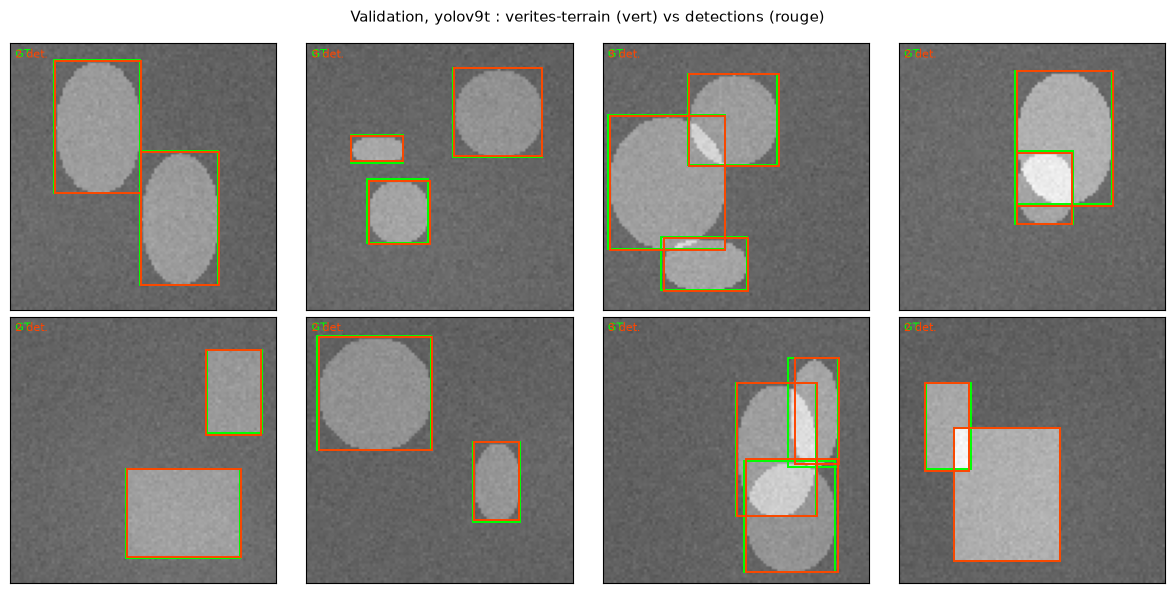

In [14]:
best_ly = max(RESULTS, key=lambda k: RESULTS[k]["ap10"])
best_model = MODEL_Y9T if best_ly == "yolov9t" else MODEL_E2E
print("meilleur mAP10 LibreYOLO :", best_ly)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])
for i, ax in enumerate(axes.flat):
    ax.imshow(Xva[i][0].numpy(), cmap="gray", vmin=-1.5, vmax=2.5)
    draw_boxes(ax, [tuple(x) for x in Bva[i].tolist()], "lime", "GT")
    dets, sc = predict_boxes_ly(best_model, i)
    det_xywh = torch.stack([dets[:, 0], dets[:, 1],
                            dets[:, 2] - dets[:, 0], dets[:, 3] - dets[:, 1]], dim=1)
    draw_boxes(ax, [tuple(x) for x in det_xywh.tolist()], "orangered",
               f"{len(det_xywh)} det.")
fig.suptitle(f"Validation, {best_ly} : verites-terrain (vert) vs detections (rouge)",
             fontsize=11)
plt.tight_layout(); plt.show()

## 8. Ce que le second wrapper achète — et ce qu'il révèle

*(lire le tableau final §7, il porte la conclusion)*

- **Le portage est presque gratuit** : même format de données, même API (`LibreYOLO(...).train(...)`), les noms changent, pas les concepts — le convertisseur du 4.5b tourne tel quel. C'est la preuve que le format YOLO est un standard de fait, et que le coût d'un second avis est faible.
- **Les recettes internes dominent à ce budget** : sur mille images, ce ne sont pas les architectures qui séparent les lignes du tableau, mais les recettes d'augmentation et de plancher d'apprentissage que chaque wrapper apporte — la leçon du 4.5b, mesurée une seconde fois ailleurs.
- **La fenêtre sans-NMS est ouverte, à variables égales** : YOLOv9-tiny et sa variante End-to-End ne diffèrent que par le régime d'appariement — la prédiction d'ensemble un-pour-un contre le post-traitement NMS. Ce que coûte et ce que rapporte l'idée de DETR dans la famille YOLO, mesuré sur le même terrain et le même budget ; les DETR-family eux-mêmes restent derrière un plancher de résolution (§5).
- **La licence est une colonne du tableau** : AGPL contre MIT, poids par checkpoint vérifiés avant usage — le second wrapper rend la question visible, et le §4 montre qu'elle se vérifie à la source en quelques lignes.


## 9. Limites et suite de la série

- **Artefacts disque** : comme au 4.5b, le format impose des fichiers — générés dans un répertoire temporaire, détruits avec la session ; un vrai pipeline les versionnerait.
- **Le sans-NMS à ce budget est un témoignage, pas un plafond** : la publication d'origine entraînait sur COCO à raison de cent cinquante époques ; six époques sur mille images disent ce que le *fine-tuning court* achète, pas ce que l'architecture vaut à maturité.
- **Les DETR-family restent derrière une contrainte de résolution** (§5) : D-FINE et RT-DETR exigent une carte d'encodeur plus grande que notre `imgsz` — le crash est mesuré à 96 comme à 128 pixels. Les revoir exige un terrain plus grand, pas un contournement.
- **Une seule classe, un seul domaine** : comme tout l'epic ; les multi-classes ne changent ni le protocole ni le pattern.
- **Projet de dix mois** : `libreyolo` est jeune ; la version réellement utilisée est affichée par la cellule d'import (`1.6.0`) et figée par les sorties committées — le paquet n'est déclaré dans aucun fichier de dépendances du dépôt : `04-Vision` n'en porte pas, contrairement à `02-ML-Cours`. C'est donc la sortie committée qui fait foi, et une re-exécution sous une autre version doit re-committer les sorties.


## Conclusion

- **Deux wrappers, un terrain, un protocole** : le même problème de détection désormais mesuré à tous les étages — from scratch (4.4), lib bas niveau (4.5), un framework (4.5b), **et un second framework (ici)** — le tableau final est le même, les lignes s'ajoutent sans changer de règles.

- **Le wrapper est un choix réversible, la licence ne l'est pas** : changer d'enseigne coûte une conversion déjà écrite ; changer de licence coûte une décision juridique. La colonne nouvelle du tableau porte cette asymétrie.

- **La fenêtre sans-NMS est dans le tableau** : YOLOv9-tiny End-to-End, appariement un-pour-un appris sur le même terrain que les ancres du 4.4 — l'arc pédagogique anchors → anchor-free → prédiction d'ensemble de l'epic trouve sa mesure, et la contrainte de résolution qui tient les DETR-family à l'écart est documentée au §5.

- **Le protocole maison reste la règle d'or** : deux wrappers, deux métriques auto-rapportées — et un seul bâton comparable, le nôtre (exercice trois).

**Références** : LibreYOLO, *LibreYOLO — an MIT-licensed vision toolkit* (2025-2026), https://github.com/LibreYOLO/libreyolo · Carion et al., *End-to-End Object Detection with Transformers* (DETR), ECCV 2020 · Wang et al., *YOLOv9: Learning What You Want to Learn Using Programmable Gradient Information*, CVPR 2024 · Jocher et al., *Ultralytics YOLO* (la référence comparative du 4.5b) · Everingham et al., *The PASCAL VOC Challenge*, IJCV 2010 (protocole mAP réutilisé) · Hugging Face, *Model Cards & Licenses* (la source des licences du §4).
